# 03 — Loss, Gradients, and Backpropagation (PyTorch)

Loss quantifies the mistake; gradients quantify parameter responsibility. Backpropagation is repeated chain rule, not a separate mysterious learning mechanism.


For softmax + cross entropy, the output sensitivity simplifies to
$$\frac{\partial \mathcal L}{\partial z^{(2)}}=\frac{1}{B}(\hat Y-Y).$$
Earlier gradients are obtained by multiplying this sensitivity backward through weights and activation derivatives.


train (5000, 784) test (1000, 784)


loss 2.3501508235931396
0.weight (16, 784) norm 2.874643325805664
0.bias (16,) norm 0.34314656257629395
2.weight (10, 16) norm 0.41142889857292175
2.bias (10,) norm 0.954340398311615


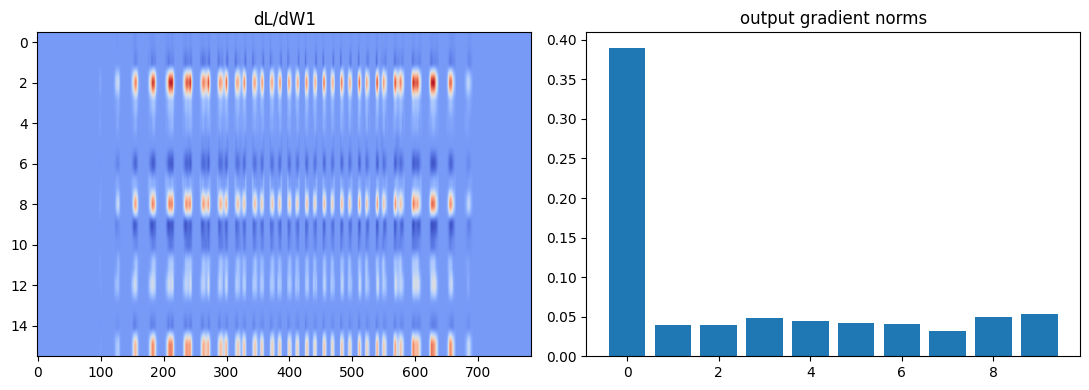

loss after one step 1.8850643634796143 before 2.3501508235931396


In [1]:
from pathlib import Path
import urllib.request, numpy as np
MNIST_URL='https://storage.googleapis.com/tensorflow/tf-keras-datasets/mnist.npz'
CACHE=Path('data/cache/mnist.npz'); CACHE.parent.mkdir(parents=True,exist_ok=True)
if not CACHE.exists():
    print('Downloading official MNIST archive...')
    urllib.request.urlretrieve(MNIST_URL,CACHE)
with np.load(CACHE) as d:
    x_train_full,y_train_full=d['x_train'],d['y_train']
    x_test_full,y_test_full=d['x_test'],d['y_test']
def balanced(x,y,n):
    ids=np.concatenate([np.flatnonzero(y==c)[:n] for c in range(10)])
    return x[ids],y[ids]
x_train_img,y_train=balanced(x_train_full,y_train_full,500)
x_test_img,y_test=balanced(x_test_full,y_test_full,100)
x_train=x_train_img.reshape(len(x_train_img),-1).astype('float32')/255.0
x_test=x_test_img.reshape(len(x_test_img),-1).astype('float32')/255.0
print('train',x_train.shape,'test',x_test.shape)

import torch,torch.nn as nn,matplotlib.pyplot as plt
torch.manual_seed(42);X=torch.tensor(x_train[:32]);Y=torch.tensor(y_train[:32],dtype=torch.long);model=nn.Sequential(nn.Linear(784,16),nn.ReLU(),nn.Linear(16,10));loss=nn.CrossEntropyLoss()(model(X),Y);print('loss',loss.item());model.zero_grad();loss.backward()
for n,p in model.named_parameters():print(n,tuple(p.grad.shape),'norm',p.grad.norm().item())
g1=model[0].weight.grad.numpy();g2=model[2].weight.grad.numpy();fig,axes=plt.subplots(1,2,figsize=(11,4));axes[0].imshow(g1,aspect='auto',cmap='coolwarm');axes[1].bar(range(10),np.linalg.norm(g2,axis=1));axes[0].set_title('dL/dW1');axes[1].set_title('output gradient norms');plt.tight_layout();plt.show();opt=torch.optim.SGD(model.parameters(),lr=.2);old=loss.item();opt.step();print('loss after one step',nn.CrossEntropyLoss()(model(X),Y).item(),'before',old)


**Cause/effect:** update parameters against the gradient → next forward pass changes → hidden representation changes → class probabilities change → loss changes.

**Production connection:** gradient scale affects convergence speed, instability, training cost, and reproducibility.
